# Numpy Autograd Demo

In this notebook, we will demonstrate our from-scratch implementation of basic machine learning framework functionality using only Python and NumPy.

## Imports

In [1]:

import os

from autograd import Tensor, cross_entropy_loss
from optimizers import SGD
from modules import FFN
from utils import Dataset, DataLoader
from datasets import load_dataset
import numpy as np

import matplotlib.pyplot as plt


## Config

In [2]:

DATA_REPO = "ylecun/mnist"
LR = 0.0001
EPOCHS = 5
BATCH_SIZE = 32


## Data

In [3]:
class MNISTDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return Tensor(
            np.array(item["image"], dtype=np.float32).flatten() / 255.0,
            requires_grad=False,
        ), Tensor(np.array([item["label"]], dtype=np.int64), requires_grad=False)

In [4]:
from datasets import Value, Sequence

data = load_dataset("ylecun/mnist")
train_data = MNISTDataset(data["train"])
test_data = MNISTDataset(data["test"])
train_data, test_data

(<__main__.MNISTDataset at 0x21181d67380>,
 <__main__.MNISTDataset at 0x211e9a1ccd0>)

In [5]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


## Training

In [6]:
model = FFN(in_features=28 * 28, hidden_features=128, out_features=10)
loss_values = []
optimizer = SGD(model.parameters, lr=LR)
criterion = cross_entropy_loss

for epoch in range(EPOCHS):
    total_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        total_loss += loss.data
        
        loss.backward()
        loss_values.append(loss.data.item())

        optimizer.step()

        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step {batch_idx+1}, Loss: {total_loss / (batch_idx + 1):.4f}")
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] completed.")



Epoch [1/5], Step 100, Loss: 2.5188
Epoch [1/5], Step 200, Loss: 2.5220
Epoch [1/5], Step 300, Loss: 2.5125
Epoch [1/5], Step 400, Loss: 2.5033
Epoch [1/5], Step 500, Loss: 2.4978
Epoch [1/5], Step 600, Loss: 2.4898
Epoch [1/5], Step 700, Loss: 2.4813
Epoch [1/5], Step 800, Loss: 2.4750
Epoch [1/5], Step 900, Loss: 2.4677
Epoch [1/5], Step 1000, Loss: 2.4602
Epoch [1/5], Step 1100, Loss: 2.4532
Epoch [1/5], Step 1200, Loss: 2.4455
Epoch [1/5], Step 1300, Loss: 2.4389
Epoch [1/5], Step 1400, Loss: 2.4329
Epoch [1/5], Step 1500, Loss: 2.4270
Epoch [1/5], Step 1600, Loss: 2.4217
Epoch [1/5], Step 1700, Loss: 2.4159
Epoch [1/5], Step 1800, Loss: 2.4101
Epoch [1/5] completed.
Epoch [2/5], Step 100, Loss: 2.2977
Epoch [2/5], Step 200, Loss: 2.2998
Epoch [2/5], Step 300, Loss: 2.2936
Epoch [2/5], Step 400, Loss: 2.2863
Epoch [2/5], Step 500, Loss: 2.2827
Epoch [2/5], Step 600, Loss: 2.2777
Epoch [2/5], Step 700, Loss: 2.2744
Epoch [2/5], Step 800, Loss: 2.2712
Epoch [2/5], Step 900, Loss: 2.2

## Evaluation

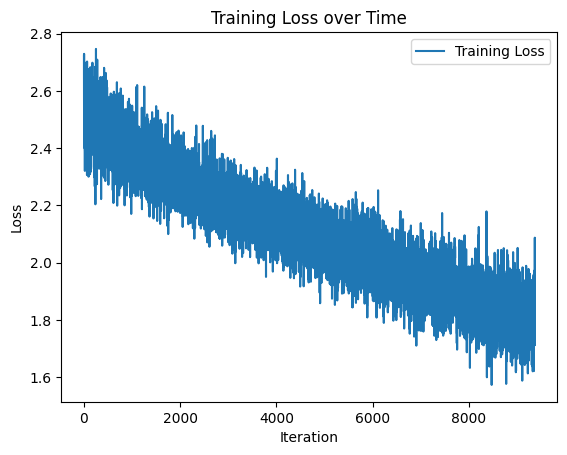

In [7]:

plt.plot(loss_values, label="Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.legend()
plt.show()

In [17]:

correct_example_images, correct_example_labels = [], []
incorrect_example_images, incorrect_example_labels, incorrect_predictions = [], [], []


test_loader = DataLoader(test_data, batch_size=5, shuffle=False)

correct = 0
total = 0

for images, labels in test_loader:
    outputs = model(images)
    predicted = np.argmax(outputs.data, axis=1)
    total += labels.shape[0]
    correct += (predicted == labels.data.flatten()).sum().item()

    if len(correct_example_images) < 5 or len(incorrect_example_images) < 5:
        for img, lbl, pred in zip(images.data, labels.data.flatten(), predicted):
            if lbl == pred:
                if len(correct_example_images) < 5:
                    correct_example_images.append(img.reshape(28, 28))
                    correct_example_labels.append(lbl)
            elif lbl != pred:
                if len(incorrect_example_images) < 5:
                    incorrect_example_images.append(img.reshape(28, 28))
                    incorrect_example_labels.append(lbl)
                    incorrect_predictions.append(pred)

print(f"Accuracy: {100 * correct / total}%")


Accuracy: 53.33%


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(1)] [np.int64(4), np.int64(4), np.int64(5), np.int64(9), np.int64(6)]
5 5


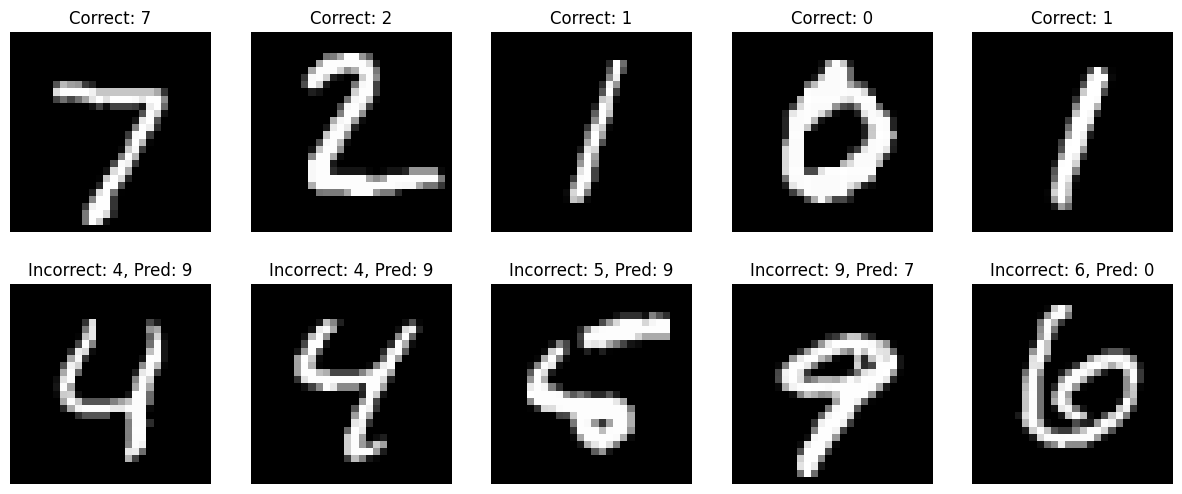

In [18]:
print(correct_example_labels, incorrect_example_labels)

print(len(correct_example_images), len(incorrect_example_images))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(correct_example_images[i], cmap="gray")
    axes[0, i].set_title(f"Correct: {correct_example_labels[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(incorrect_example_images[i], cmap="gray")
    axes[1, i].set_title(f"Incorrect: {incorrect_example_labels[i]}, Pred: {incorrect_predictions[i]}")
    axes[1, i].axis("off")
plt.show()
